In [1]:
import pandas as pd
import seaborn as sns

In [2]:
emp_df = pd.read_csv("employee_turnover.csv")
emp_df.head()
emp_df.columns

Index(['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company',
       'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income',
       'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role',
       'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared',
       'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover'],
      dtype='object')

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [4]:
X = emp_df.drop("Employee_Turnover",axis=1)
Y = emp_df["Employee_Turnover"]
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.2,random_state=42
)

In [5]:
model = LogisticRegression()

In [6]:
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
Y_pred = model.predict(X_test)

In [8]:
print("Accuracy Score :",accuracy_score(Y_test,Y_pred)*100,"%")
print("Precision Score :",precision_score(Y_test,Y_pred)*100,"%")
print("Recall Score :",recall_score(Y_test,Y_pred)*100,"%")
print("F1 Score :",f1_score(Y_test,Y_pred)*100,"%")

Accuracy Score : 84.07407407407408 %
Precision Score : 82.66423357664233 %
Recall Score : 85.47169811320755 %
F1 Score : 84.04452690166976 %


# Following the an updated WORKFLOW

                 Employee Dataset
                       │
                       ▼
                Data Inspection
                       │
                       ▼
                 Remove Duplicates
                       │
                       ▼
                Train/Test Split
                       │
                       ▼
             Feature Preprocessing
             ┌─────────┴─────────┐
             │                   │
       Standardization      Encoding
             │                   │
             └─────────┬─────────┘
                       ▼
              Feature Engineering
                       │
                       ▼
                Feature Selection
                       │
             ┌─────────┴─────────┐
             ▼                   ▼
       Logistic L1          Logistic L2
             │                   │
             └─────────┬─────────┘
                       ▼
                Cross Validation
                       │
                       ▼
                Hyperparameter
                   Tuning
                       │
                       ▼
                 Model Comparison
                       │
                       ▼
                  Best Model

In [13]:
emp_df.shape
emp_df = emp_df.drop_duplicates()

In [16]:
emp_df.shape

(900, 16)

In [17]:
emp_df.columns

Index(['Job_Satisfaction', 'Performance_Rating', 'Years_At_Company',
       'Work_Life_Balance', 'Distance_From_Home', 'Monthly_Income',
       'Education_Level', 'Age', 'Num_Companies_Worked', 'Employee_Role',
       'Annual_Bonus', 'Training_Hours', 'Department', 'Annual_Bonus_Squared',
       'Annual_Bonus_Training_Hours_Interaction', 'Employee_Turnover'],
      dtype='object')

In [19]:
X = emp_df.drop("Employee_Turnover",axis=1)
Y = emp_df["Employee_Turnover"]

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler",StandardScaler()),
    ("logistic",LogisticRegression(max_iter=5000))
])

In [25]:
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

In [26]:
print("Accuracy :", accuracy_score(Y_test, Y_pred) * 100)
print("Precision:", precision_score(Y_test, Y_pred) * 100)
print("Recall   :", recall_score(Y_test, Y_pred) * 100)
print("F1 Score :", f1_score(Y_test, Y_pred) * 100)

Accuracy : 87.77777777777777
Precision: 89.28571428571429
Recall   : 85.22727272727273
F1 Score : 87.20930232558139


In [27]:
l1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1,
        max_iter=5000
    ))
])

l1_model.fit(X_train, Y_train)

Y_pred_l1 = l1_model.predict(X_test)

print("L1 Accuracy :", accuracy_score(Y_test, Y_pred_l1) * 100)
print("L1 Precision:", precision_score(Y_test, Y_pred_l1) * 100)
print("L1 Recall   :", recall_score(Y_test, Y_pred_l1) * 100)
print("L1 F1 Score :", f1_score(Y_test, Y_pred_l1) * 100)

L1 Accuracy : 87.22222222222223
L1 Precision: 89.1566265060241
L1 Recall   : 84.0909090909091
L1 F1 Score : 86.54970760233918


In [28]:
l2_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        penalty="l2",
        C=1,
        max_iter=5000
    ))
])

l2_model.fit(X_train, Y_train)

Y_pred_l2 = l2_model.predict(X_test)

print("L2 Accuracy :", accuracy_score(Y_test, Y_pred_l2) * 100)
print("L2 Precision:", precision_score(Y_test, Y_pred_l2) * 100)
print("L2 Recall   :", recall_score(Y_test, Y_pred_l2) * 100)
print("L2 F1 Score :", f1_score(Y_test, Y_pred_l2) * 100)

L2 Accuracy : 87.77777777777777
L2 Precision: 89.28571428571429
L2 Recall   : 85.22727272727273
L2 F1 Score : 87.20930232558139


In [29]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        solver="liblinear",
        max_iter=5000
    ))
])

param_grid = {
    "logistic__penalty": ["l1", "l2"],
    "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, Y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'logistic__C': [0.001, 0.01, ...], 'logistic__penalty': ['l1', 'l2']}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [30]:
print("Best Parameters:")
print(grid.best_params_)

print("Best CV F1 Score:")
print(grid.best_score_)

Best Parameters:
{'logistic__C': 1, 'logistic__penalty': 'l1'}
Best CV F1 Score:
0.856556983422655


In [31]:
best_model = grid.best_estimator_

Y_pred_best = best_model.predict(X_test)

print("Accuracy :", accuracy_score(Y_test, Y_pred_best) * 100)
print("Precision:", precision_score(Y_test, Y_pred_best) * 100)
print("Recall   :", recall_score(Y_test, Y_pred_best) * 100)
print("F1 Score :", f1_score(Y_test, Y_pred_best) * 100)

Accuracy : 87.22222222222223
Precision: 89.1566265060241
Recall   : 84.0909090909091
F1 Score : 86.54970760233918


In [32]:
coefficients = best_model.named_steps["logistic"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

print(feature_importance)

                                    Feature  Coefficient
0                          Job_Satisfaction     1.798900
1                        Performance_Rating     1.775410
3                         Work_Life_Balance     1.745515
4                        Distance_From_Home     1.587108
2                          Years_At_Company     1.444045
6                           Education_Level    -0.304671
13                     Annual_Bonus_Squared     0.173453
12                               Department    -0.169288
9                             Employee_Role     0.132354
14  Annual_Bonus_Training_Hours_Interaction    -0.077340
8                      Num_Companies_Worked    -0.044012
5                            Monthly_Income    -0.025136
7                                       Age    -0.023774
10                             Annual_Bonus    -0.023189
11                           Training_Hours     0.000000


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred_best)

print(cm)

[[83  9]
 [14 74]]


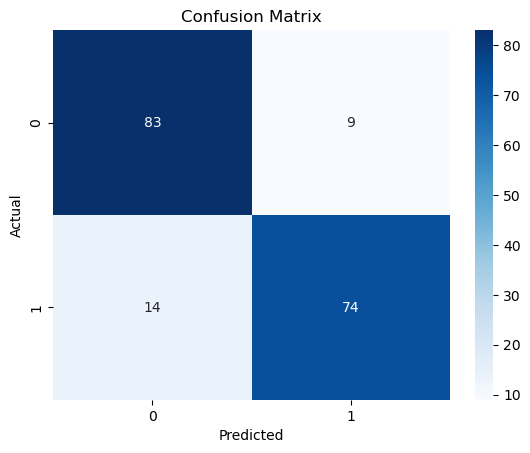

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
probabilities = best_model.predict_proba(X_test)[:, 1]